<a href="https://colab.research.google.com/github/mariabandeira/Alura-Store-Brasil/blob/main/AluraStoreBrasil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importação dos dados



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [ ]:
faturamento_loja = loja['Preço'].sum()
faturamento_loja2 = loja2['Preço'].sum()
faturamento_loja3 = loja3['Preço'].sum()
faturamento_loja4 = loja4['Preço'].sum()

In [ ]:
print(f'O faturamento da loja 1 foi de R${faturamento_loja}')
print(f'O faturamento da loja 2 foi de R${faturamento_loja2}')
print(f'O faturamento da loja 3 foi de R${faturamento_loja3}')
print(f'O faturamento da loja 4 foi de R${faturamento_loja4}')

O faturamento da loja 1 foi de R$1534509.12
O faturamento da loja 2 foi de R$1488459.06
O faturamento da loja 3 foi de R$1464025.03
O faturamento da loja 4 foi de R$1384497.58


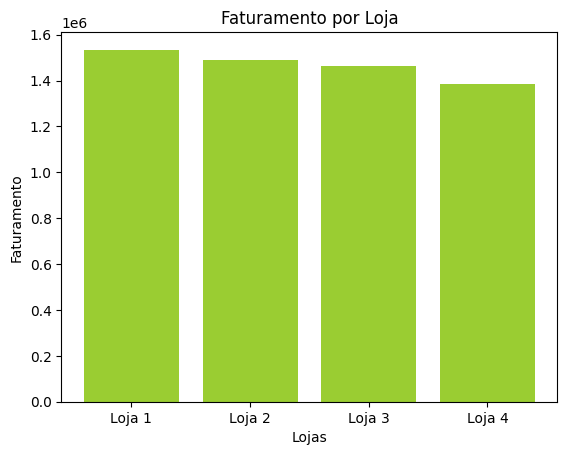

In [ ]:
# Gráfico de barra vertical do faturamento
import matplotlib.pyplot as plt

faturamentos = [faturamento_loja, faturamento_loja2, faturamento_loja3, faturamento_loja4]
lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']
plt.bar(lojas, faturamentos, color='yellowgreen')
plt.xlabel('Lojas')
plt.ylabel('Faturamento')
plt.title('Faturamento por Loja')
plt.show()

# 2. Vendas por Categoria

In [ ]:
def vendas_por_categoria(df, column):
    vendas_por_categoria = df[column].value_counts()
    return vendas_por_categoria

In [ ]:
stores = {'LOJA 1': loja, 'LOJA 2': loja2, 'LOJA 3': loja3, 'LOJA 4': loja4}

for name, df in stores.items():
    print(f"{name}")
    display(vendas_por_categoria(df, 'Categoria do Produto'))
    print("\n" + "-"*50 + "\n")

LOJA 1


,count
Categoria do Produto,
moveis,465
eletronicos,448
brinquedos,324
eletrodomesticos,312
esporte e lazer,284
instrumentos musicais,182
livros,173
utilidades domesticas,171



--------------------------------------------------

LOJA 2


,count
Categoria do Produto,
moveis,442
eletronicos,422
brinquedos,313
eletrodomesticos,305
esporte e lazer,275
instrumentos musicais,224
livros,197
utilidades domesticas,181



--------------------------------------------------

LOJA 3


,count
Categoria do Produto,
moveis,499
eletronicos,451
brinquedos,315
eletrodomesticos,278
esporte e lazer,277
livros,185
instrumentos musicais,177
utilidades domesticas,177



--------------------------------------------------

LOJA 4


,count
Categoria do Produto,
moveis,480
eletronicos,451
brinquedos,338
esporte e lazer,277
eletrodomesticos,254
utilidades domesticas,201
livros,187
instrumentos musicais,170



--------------------------------------------------



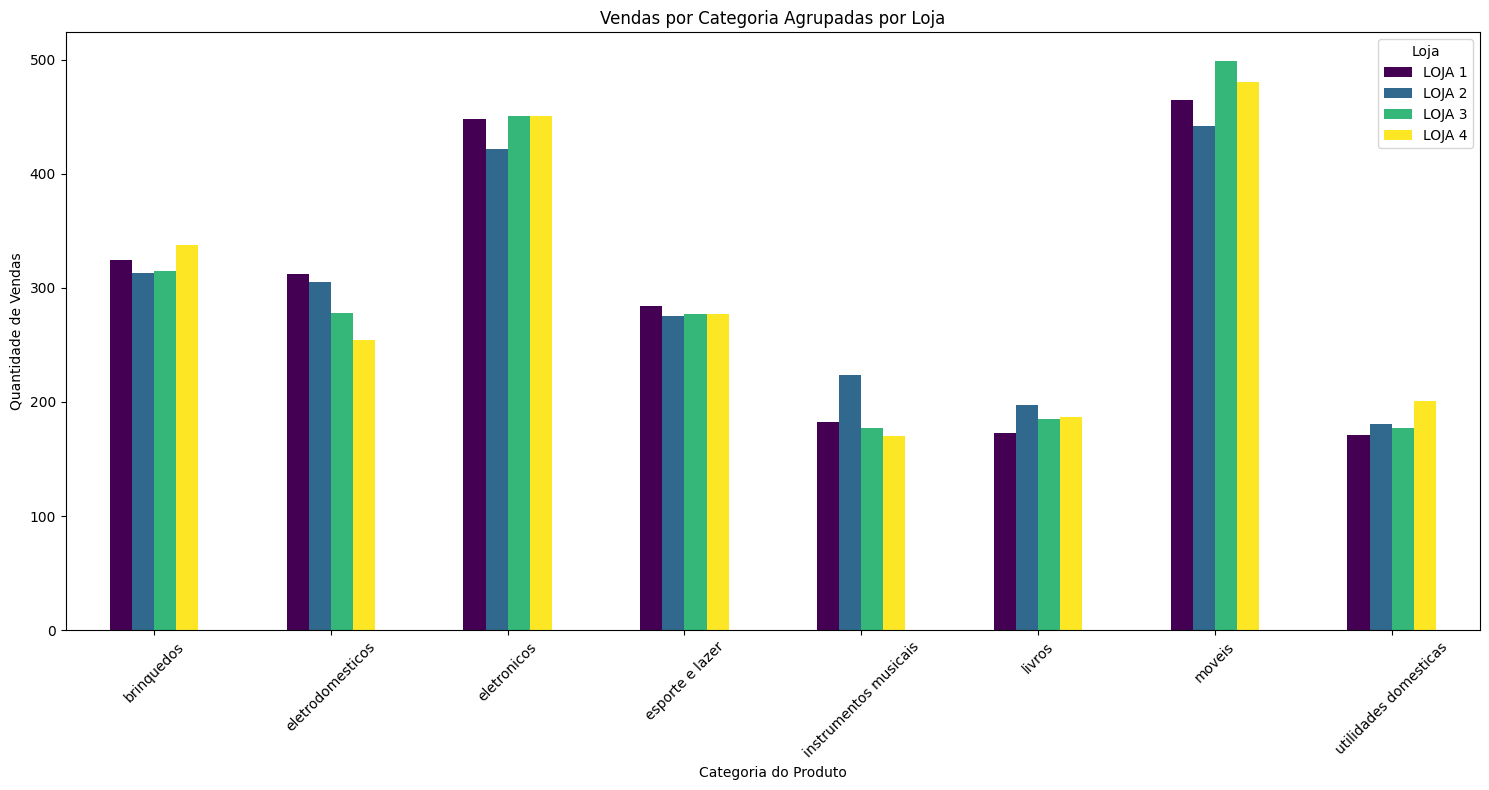

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

all_vendas = []
for name, df in stores.items():
    counts = df['Categoria do Produto'].value_counts().rename_axis('Categoria').reset_index(name='Vendas')
    counts['Loja'] = name
    all_vendas.append(counts)
vendas_df = pd.concat(all_vendas)
vendas_pivot = vendas_df.pivot_table(index='Categoria', columns='Loja', values='Vendas', fill_value=0)
vendas_pivot = vendas_pivot.sort_index()

fig, ax = plt.subplots(figsize=(15, 8))

vendas_pivot.plot(kind='bar', ax=ax, cmap='viridis')

ax.set_title('Vendas por Categoria Agrupadas por Loja')
ax.set_xlabel('Categoria do Produto')
ax.set_ylabel('Quantidade de Vendas')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Loja')
plt.tight_layout()
plt.show()

# 3. Média de Avaliação das Lojas


In [ ]:
media_avaliacao_loja = loja['Avaliação da compra'].mean()
media_avaliacao_loja2 = loja2['Avaliação da compra'].mean()
media_avaliacao_loja3 = loja3['Avaliação da compra'].mean()
media_avaliacao_loja4 = loja4['Avaliação da compra'].mean()

In [ ]:
print(f'A média das avaliações da loja 1 foi de {media_avaliacao_loja:.2f}')
print(f'A média das avaliações da loja 2 foi de {media_avaliacao_loja2:.2f}')
print(f'A média das avaliações da loja 3 foi de {media_avaliacao_loja3:.2f}')
print(f'A média das avaliações da loja 4 foi de {media_avaliacao_loja4:.2f}')

A média das avaliações da loja 1 foi de 3.98
A média das avaliações da loja 2 foi de 4.04
A média das avaliações da loja 3 foi de 4.05
A média das avaliações da loja 4 foi de 4.00


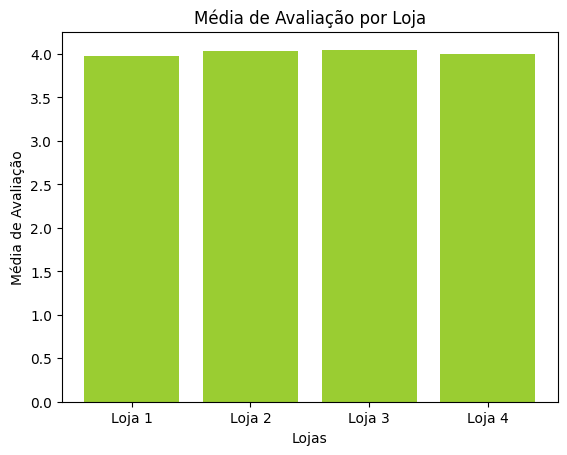

In [ ]:
# grafico de barra das medias de avaliações por loja
import matplotlib.pyplot as plt

avaliacoes = [media_avaliacao_loja, media_avaliacao_loja2, media_avaliacao_loja3, media_avaliacao_loja4]
lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']

plt.bar(lojas, avaliacoes, color='yellowgreen')
plt.xlabel('Lojas')
plt.ylabel('Média de Avaliação')
plt.title('Média de Avaliação por Loja')
plt.show()

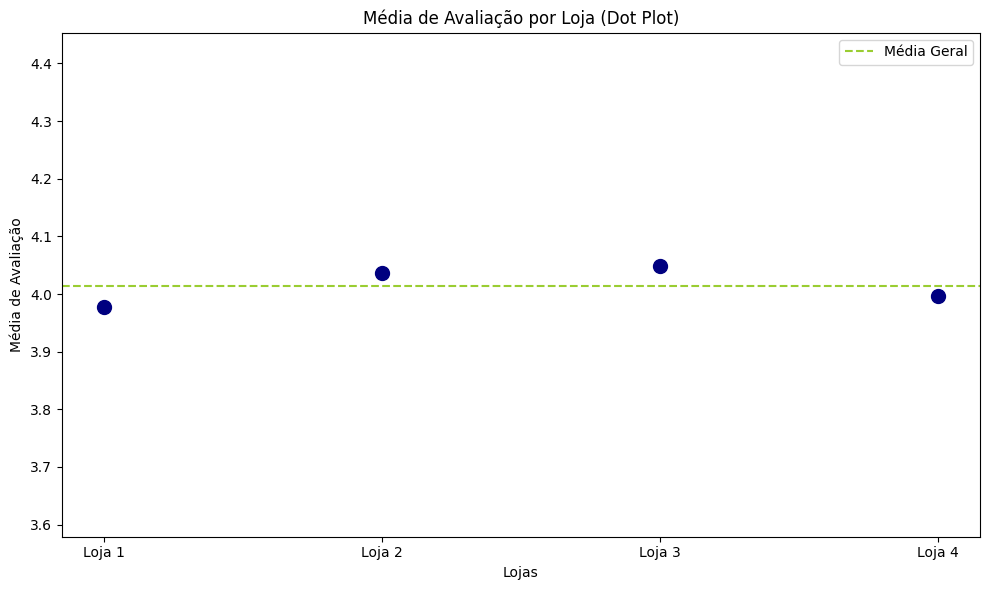

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(lojas, avaliacoes, 'o', color='navy', markersize=10)

overall_average = sum(avaliacoes) / len(avaliacoes)
plt.axhline(y=overall_average, color='yellowgreen', linestyle='--', label='Média Geral')

plt.xlabel('Lojas')
plt.ylabel('Média de Avaliação')
plt.title('Média de Avaliação por Loja (Dot Plot)')
plt.ylim(min(avaliacoes) * 0.9, max(avaliacoes) * 1.1)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Produtos Mais e Menos Vendidos

In [ ]:
stores = {'LOJA 1': loja, 'LOJA 2': loja2, 'LOJA 3': loja3, 'LOJA 4': loja4}

for name, df in stores.items():
    print(f"{name}")
    print(f"Produtos mais vendidos da {name}")
    display(df['Produto'].value_counts().head())
    print(f"\nProdutos menos vendidos da {name}")
    display(df['Produto'].value_counts().tail())
    print("\n" + "-"*50 + "\n")

LOJA 1
Produtos mais vendidos da LOJA 1


,count
Produto,
Micro-ondas,60
TV Led UHD 4K,60
Guarda roupas,60
Secadora de roupas,58
Cômoda,56



Produtos menos vendidos da LOJA 1


,count
Produto,
Ciência de dados com python,39
Pandeiro,36
Panela de pressão,35
Headset,33
Celular ABXY,33



--------------------------------------------------

LOJA 2
Produtos mais vendidos da LOJA 2


...


--------------------------------------------------

LOJA 4
Produtos mais vendidos da LOJA 4


,count
Produto,
Cama box,62
Faqueiro,59
Dashboards com Power BI,56
Cama king,56
Carrinho controle remoto,55



Produtos menos vendidos da LOJA 4


,count
Produto,
Geladeira,38
Ciência de dados com python,38
Violão,37
Guarda roupas,34
Guitarra,33



--------------------------------------------------



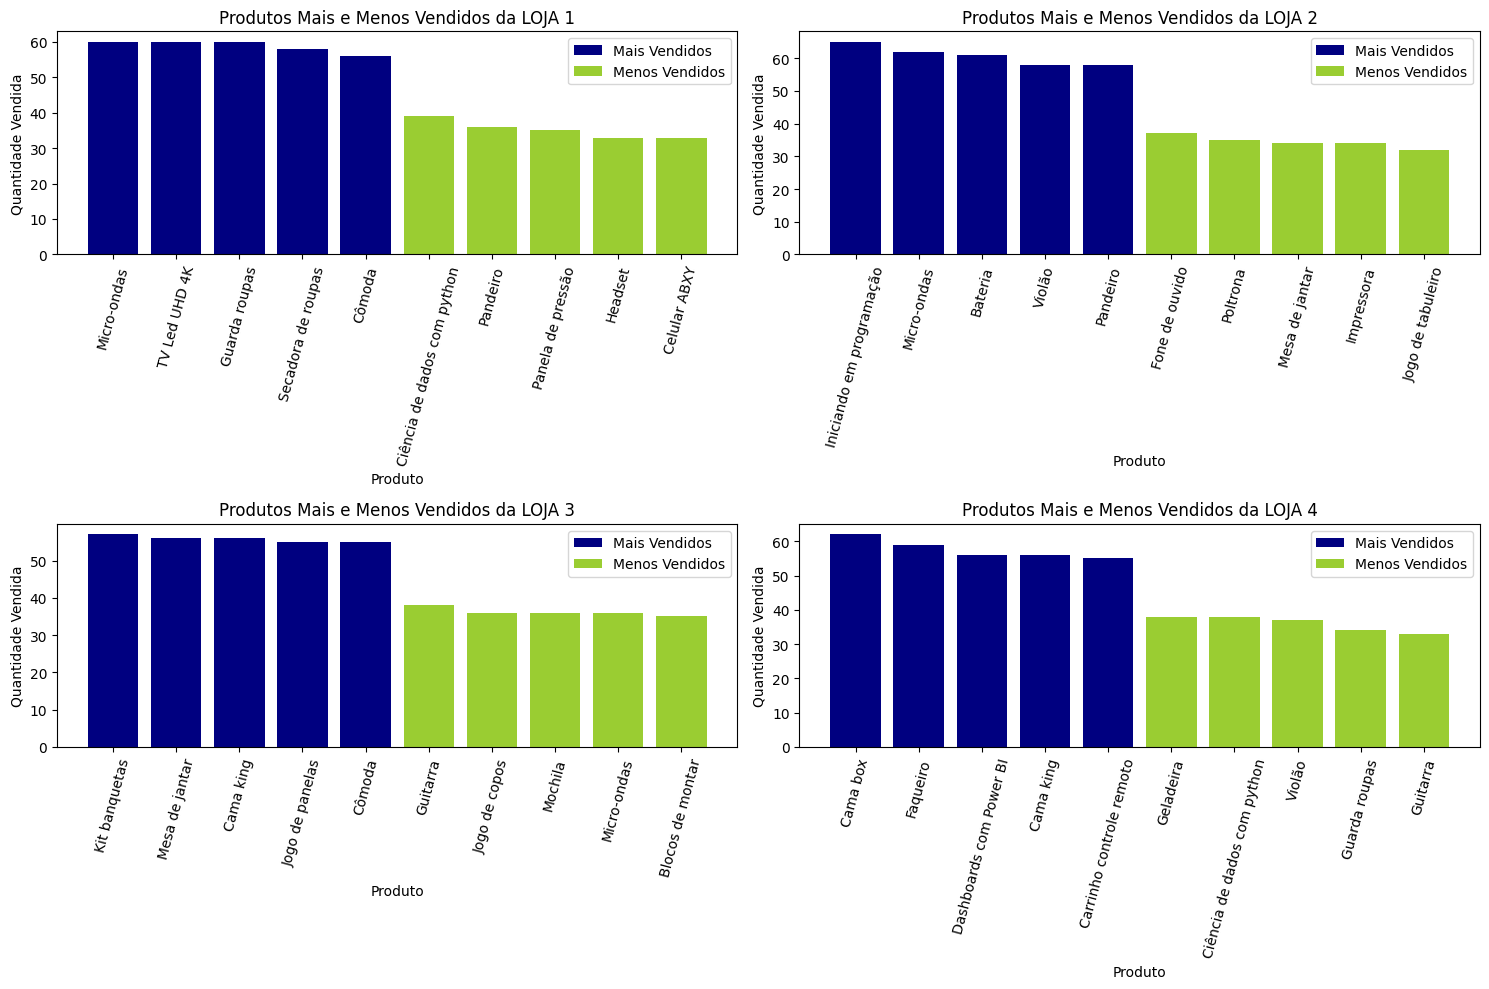

In [ ]:
# grafico dos produtos mais e menos vendidos por loja
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (name, df) in enumerate(stores.items()):
    ax = axes[i]
    mais_vendidos = df['Produto'].value_counts().head()
    menos_vendidos = df['Produto'].value_counts().tail()
    ax.bar(mais_vendidos.index, mais_vendidos.values, label='Mais Vendidos', color='navy')
    ax.bar(menos_vendidos.index, menos_vendidos.values, label='Menos Vendidos', color='yellowgreen')
    ax.set_xlabel('Produto')
    ax.set_ylabel('Quantidade Vendida')
    ax.set_title(f'Produtos Mais e Menos Vendidos da {name}')
    ax.legend()
    ax.tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

# 5. Frete Médio por Loja

In [ ]:
media_frete_loja = loja['Frete'].mean()
media_frete_loja2 = loja2['Frete'].mean()
media_frete_loja3 = loja3['Frete'].mean()
media_frete_loja4 = loja4['Frete'].mean()

In [ ]:
print(f'A média do frete da loja 1 foi de {media_frete_loja:.2f}')
print(f'A média do frete da loja 2 foi de {media_frete_loja2:.2f}')
print(f'A média do frete da loja 3 foi de {media_frete_loja3:.2f}')
print(f'A média do frete da loja 4 foi de {media_frete_loja4:.2f}')

A média do frete da loja 1 foi de 34.69
A média do frete da loja 2 foi de 33.62
A média do frete da loja 3 foi de 33.07
A média do frete da loja 4 foi de 31.28


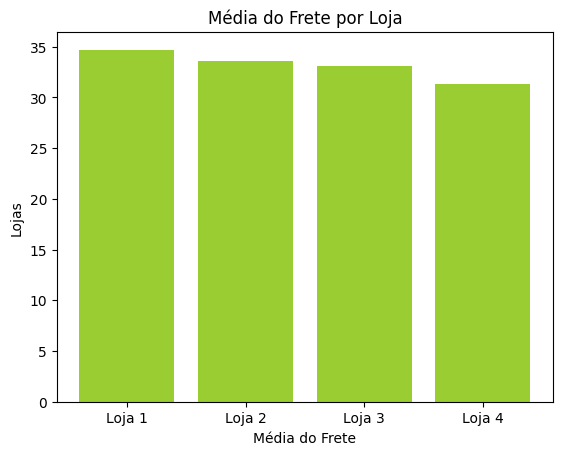

In [ ]:
# grafico de barra horizontal para frete medio por loja
import matplotlib.pyplot as plt

frete = [media_frete_loja, media_frete_loja2, media_frete_loja3, media_frete_loja4]
lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']

plt.bar(lojas, frete, color='yellowgreen')
plt.ylabel('Lojas')
plt.xlabel('Média do Frete')
plt.title('Média do Frete por Loja')
plt.show()

# Relatório Final

## 1. O Que Analisamos
- Faturamento
- Vendas por categoria
- Média de avaliação das lojas
- Produtos mais e menos vendidos
- Frete médio por loja

## 2. Principais Insights

- Loja 1 possui o maior faturamento dentre as lojas
- Móveis e Eletrônicos se destacam nas vendas por categoria em todas as lojas
- As médias de avaliação são boas para todas as lojas, com leve destaque para a Loja 3
- Loja 4 possui a menor média de frete

## 3. Recomendação Final
Recomenda-se vender a loja 4

- Possui o menor faturamento
- Não possui categoria líder que se destaque
- Possui o frete mais baixo, o que é uma vantagem para o consumidor, mas não é o suficiente para compensar o baixo retorno
- Focar nas Lojas 1, 2 e 3 vai gerar mais potencial de crescimento e rentabilidade